# AFCON 2023 Final: Data Analysis
###  Nigeria 🇳🇬 vs Ivory Coast 🇨🇮 | February 11, 2024
### Notebook Series: Part A: Individual Player's Pass Map

### Task

Using `StatsBomb` event data, load the AFCON 2023 Final between Nigeria and Ivory Coast, select a player from the Ivory Coast squad, and visualize all passes made by that player during the match on a football pitch using `mplsoccer`.

---

> **Data Source:** [StatsBomb Open Data](https://github.com/statsbomb/open-data)
> 
> **competition_id:** = 1267
>  
> **season_id:** = 107
> 
> **match_id:** = 3923881
> 
> **Player Analysed:** Seri

---

## 1. Environment Setup

### 1.1 Import Libraries

We import `pandas` and `numpy` for data manipulation and numerical operations, 
`matplotlib.pyplot` for figure rendering, `matplotlib.patheffects` for text 
styling effects, `matplotlib.patches` for legend elements, and `mplsoccer` — 
specifically `Pitch` and `Sbopen` for pitch drawing and StatsBomb data access.

In [18]:
# import core libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from mplsoccer import Pitch, Sbopen, VerticalPitch

### 1.2 Load Competitions and Matches Using `Sbopen`

We use `Sbopen` to load all available StatsBomb competitions and matches, 
then select the **AFCON 2023 Final** | Ivory Coast vs Nigeria | using 
`match_id = 3923881`.

In [20]:
# Load competition and matches 
parser = Sbopen()

# 1. List competitions 
df_comp = parser.competition()
df_comp.head()

,competition_id,season_id,country_name,competition_name,competition_gender,competition_youth,competition_international,season_name,match_updated,match_updated_360,match_available_360,match_available
0,9,281,Germany,1. Bundesliga,male,False,False,2023/2024,2024-09-28T20:46:38.893391,2025-11-15T23:17:41.827093,2025-11-15T23:17:41.827093,2024-09-28T20:46:38.893391
1,9,27,Germany,1. Bundesliga,male,False,False,2015/2016,2024-05-19T11:11:14.192381,None,None,2024-05-19T11:11:14.192381
2,1267,107,Africa,African Cup of Nations,male,False,True,2023,2026-05-12T21:18:08.827431,2026-05-02T02:07:18.902396,2026-05-02T02:07:18.902396,2026-05-12T21:18:08.827431
3,16,4,Europe,Champions League,male,False,False,2018/2019,2026-05-15T15:54:04.598614,2021-06-13T16:17:31.694,None,2026-05-15T15:54:04.598614
4,16,1,Europe,Champions League,male,False,False,2017/2018,2024-02-13T02:35:28.134882,2021-06-13T16:17:31.694,None,2024-02-13T02:35:28.134882


### 1.3 Load Match Events

Load the full event data for the selected match using `parser.event(match_id)`.

In [21]:
# Select the competition id, season id and match id
competition_id = 1267
season_id = 107
match_id = 3923881

# Load matches for that competition and season
df_match = parser.match(competition_id, season_id)

# Display only the AFCON 2023 Final
df_match[df_match['match_id'] == match_id][['competition_id', 'season_id', 'match_id', 'home_team_name', 'away_team_name']]

,competition_id,season_id,match_id,home_team_name,away_team_name
24,1267,107,3923881,Nigeria,Côte d'Ivoire


In [22]:
# Load all events
# Load all events for the selected match
df, related, freeze, tactics = parser.event(match_id)
df.head()

,id,index,period,timestamp,minute,second,possession,duration,match_id,type_id,...,block_offensive,foul_committed_offensive,bad_behaviour_card_id,bad_behaviour_card_name,substitution_replacement_id,substitution_replacement_name,pass_goal_assist,pass_cut_back,foul_committed_card_id,foul_committed_card_name
0,43446b4c-472f-4c9b-a6c8-c40fd9d38328,1,1,00:00:00,0,0,1,0.000000,3923881,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5195a0f0-95db-4cb4-bbaa-b9dd05f2114e,2,1,00:00:00,0,0,1,0.000000,3923881,35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,06b5ec1f-cab0-4bbc-ab5e-d88e5b2ffdbc,3,1,00:00:00,0,0,1,0.000000,3923881,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,8252893b-c231-487c-83ad-b4a167b63bc8,4,1,00:00:00,0,0,1,0.000000,3923881,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8b8272c8-f07f-4514-96a7-413cc3c7f4f5,5,1,00:00:00.663000,0,0,2,1.773278,3923881,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.4 Filter Pass Events

From the full event data, keep only rows where `type_name == 'Pass'`, 
then filter further to retain only passes made by **Jean Michaël Seri**.

In [23]:
# Select only pass events
passes = df[df['type_name'] == 'Pass'].copy()


# All players that made passes
passes['player_name'].value_counts().head(20)

player_name
Ghislain Konan                         77
Jean Michaël Seri                      66
Obite Evan Ndicka                      55
Odilon Kossonou                        55
Simon Adingra                          40
Calvin Bassey Ughelumba                38
Serge Aurier                           37
Franck Yannick Kessié                  33
William Troost-Ekong                   29
Temitayo Olufisayo Olaoluwa Aina       29
Seko Fofana                            29
Zaidu Sanusi                           28
Stanley Bobo Nwabali                   27
Oluwasemilogo Adesewo Ibidapo Ajayi    25
Max-Alain Gradel                       23
Alex Iwobi                             21
Yahia Fofana                           17
Ademola Lookman                        14
Moses Daddy-Ajala Simon                14
Sébastien Haller                       12
Name: count, dtype: int64

In [24]:
# Select a specific player 
player_name = 'Jean Michaël Seri'
player_passes = passes[passes['player_name'] == player_name].copy()

### 1.5 Filter Passes by Outcome
Split passes into **completed** (where `outcome_name` is `NaN`) and 
**incomplete** (where `outcome_name` is not null).

In [25]:
# completed vs incompleted 
completed = player_passes[player_passes['outcome_name'].isna()].copy()
incomplete = player_passes[player_passes['outcome_name'].notna()].copy()

print("Total Passes:", len(player_passes))
print("Completed Passes:", len(completed))
print("Iompleted Passes:", len(incomplete))

Total Passes: 66
Completed Passes: 61
Iompleted Passes: 5


### 1.6 Visualize the Pass Map

Plot all passes on a **StatsBomb pitch** using `Pitch` from `mplsoccer` with:
- a dark background (`pitch_color="#050816"`)
- **green arrows** for completed passes
- **red arrows** for incomplete passes
- a legend explaining both categories

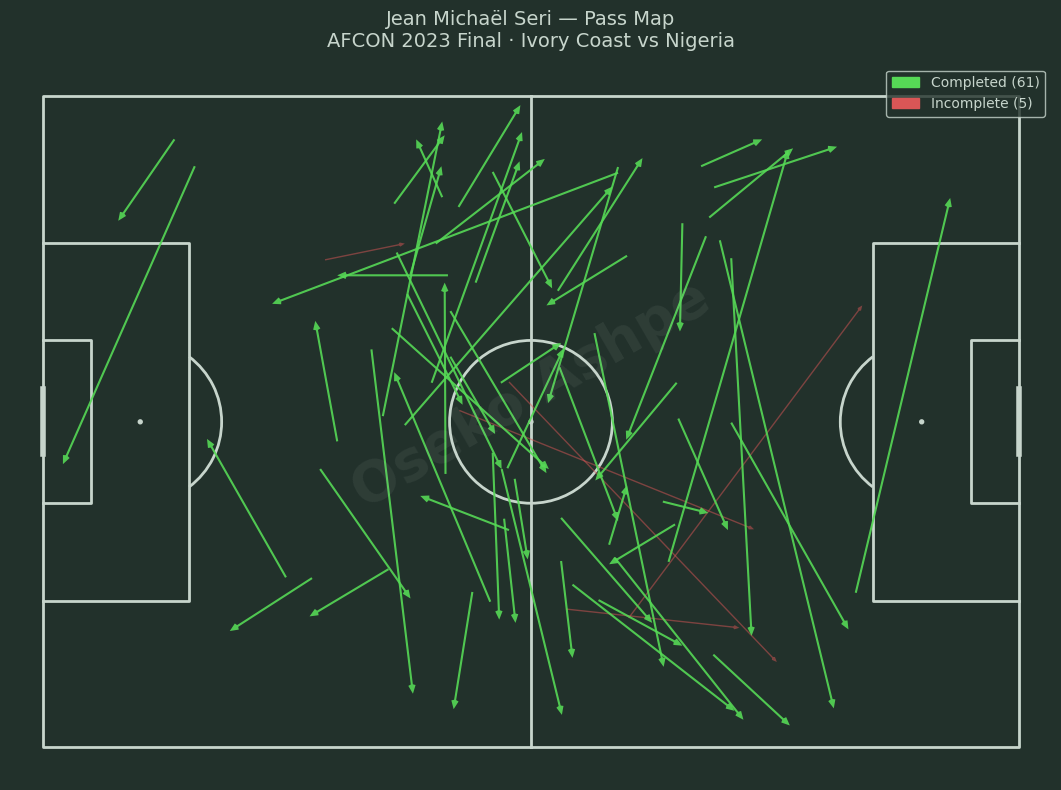

In [38]:
# Create pitch
pitch = Pitch(
    pitch_type="statsbomb",
    pitch_color="#22312b",
    line_color="#c7d5cc"
)

fig, ax = pitch.draw(figsize=(12, 8))
fig.set_facecolor("#22312b")

# Completed passes
pitch.arrows(
    completed["x"], completed["y"],
    completed["end_x"], completed["end_y"],
    ax=ax,
    color="#56d956",
    width=1.5,
    headwidth=3.5,
    headlength=4,
    alpha=0.9,
    zorder=3
)

# Incomplete passes
pitch.arrows(
    incomplete["x"], incomplete["y"],
    incomplete["end_x"], incomplete["end_y"],
    ax=ax,
    color="#d95656",
    width=1.0,
    headwidth=3,
    headlength=3.5,
    alpha=0.5,
    zorder=2
)

player_name = player_passes["player_name"].iloc[0]
ax.set_title(f"{player_name} — Pass Map\nAFCON 2023 Final · Ivory Coast vs Nigeria",
             fontsize=14, color="#c7d5cc", pad=12)

completed_patch  = mpatches.Patch(color="#56d956", label=f"Completed ({len(completed)})")
incomplete_patch = mpatches.Patch(color="#d95656", label=f"Incomplete ({len(incomplete)})")

ax.legend(handles=[completed_patch, incomplete_patch],
          facecolor="#22312b", edgecolor="#c7d5cc",
          labelcolor="#c7d5cc", fontsize=10)

fig.text(0.5, 0.5, "Oseko Ashpe",
         fontsize=40, color="#c7d5cc",
         alpha=0.08, ha="center", va="center",
         fontweight="bold", rotation=30)

plt.tight_layout()
plt.show()

# 3. Interpretation of the Pass Map

The pass map shows all passes attempted by `Michael Seri` for Ivory Coast in the match against Nigeria `competition_id = 1267`, `season_id = 107`, `match_id =  3923881`). 
All succesful passes are represented by green arrows and unsuccesful ones are drawn in red arrows, on a dark green statsbomb pitch. 